# Norman Subgroup Comparison

Compare `TriShift`, `Scouter`, `GenePert`, and `GEARS` across Norman subgroup strata, similar in purpose to Scouter `Fig2_fg`, but using the metrics and file layout in this repo.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.baseline_panel as baseline_panel
from scripts.trishift.analysis._result_adapter import parse_models, parse_split_ids, resolve_result, load_metrics_df
from trishift._utils import normalize_condition

sns.set_style("whitegrid")
repo_root


WindowsPath('e:/CODE/trishift')

## Parameters


In [2]:
dataset = "norman"
models = ["trishift_nearest",  "genepert", "gears"]
split_ids = [1, 2, 3, 4, 5]
metric_map = {
    "pearson": "Pearson",
    "nmse": "NMSE",
    "deg_mean_r2": "DEG mean R2",
}
out_root = repo_root / "notebooks" / "artifacts" / "norman_subgroup_compare"
out_root.mkdir(parents=True, exist_ok=True)
model_order = ["trishift_nearest", "scouter", "genepert", "gears"]
palette = {
    "trishift_nearest": "#1f77b4",
    "scouter": "#f2b701",
    "genepert": "#2ca02c",
    "gears": "#d62728",
}


In [3]:
rows = []
for model_name in parse_models(models):
    resolved = resolve_result(dataset=dataset, model_name=model_name, systema_root=None)
    metrics_df = load_metrics_df(resolved)
    metrics_df = metrics_df[metrics_df["split_id"].isin(parse_split_ids(split_ids))].copy()
    metrics_df["condition"] = metrics_df["condition"].astype(str).map(normalize_condition)
    if "subgroup" not in metrics_df.columns:
        raise ValueError(f"metrics for {model_name} do not contain subgroup column")
    metrics_df["model_name"] = model_name
    rows.append(metrics_df)

all_df = pd.concat(rows, ignore_index=True)
all_df = all_df[all_df["subgroup"].astype(str).isin(["seen0", "seen1", "seen2"])].copy()
summary_df = all_df.groupby(["model_name", "subgroup"], as_index=False)[list(metric_map.keys())].median(numeric_only=True)
summary_df.to_csv(out_root / "norman_subgroup_metrics.csv", index=False, encoding="utf-8-sig")
display(summary_df)


,model_name,subgroup,pearson,nmse,deg_mean_r2
0,gears,seen0,0.926052,0.236285,0.723011
1,gears,seen1,0.922257,0.280116,0.697422
2,gears,seen2,0.888388,0.309731,0.623199
3,genepert,seen0,0.953284,0.166936,0.743805
4,genepert,seen1,0.968119,0.144370,0.800600
5,genepert,seen2,0.973469,0.172167,0.803445
6,trishift_nearest,seen0,0.948216,0.114013,0.846130
7,trishift_nearest,seen1,0.979222,0.083445,0.905160
8,trishift_nearest,seen2,0.981113,0.075733,0.910889


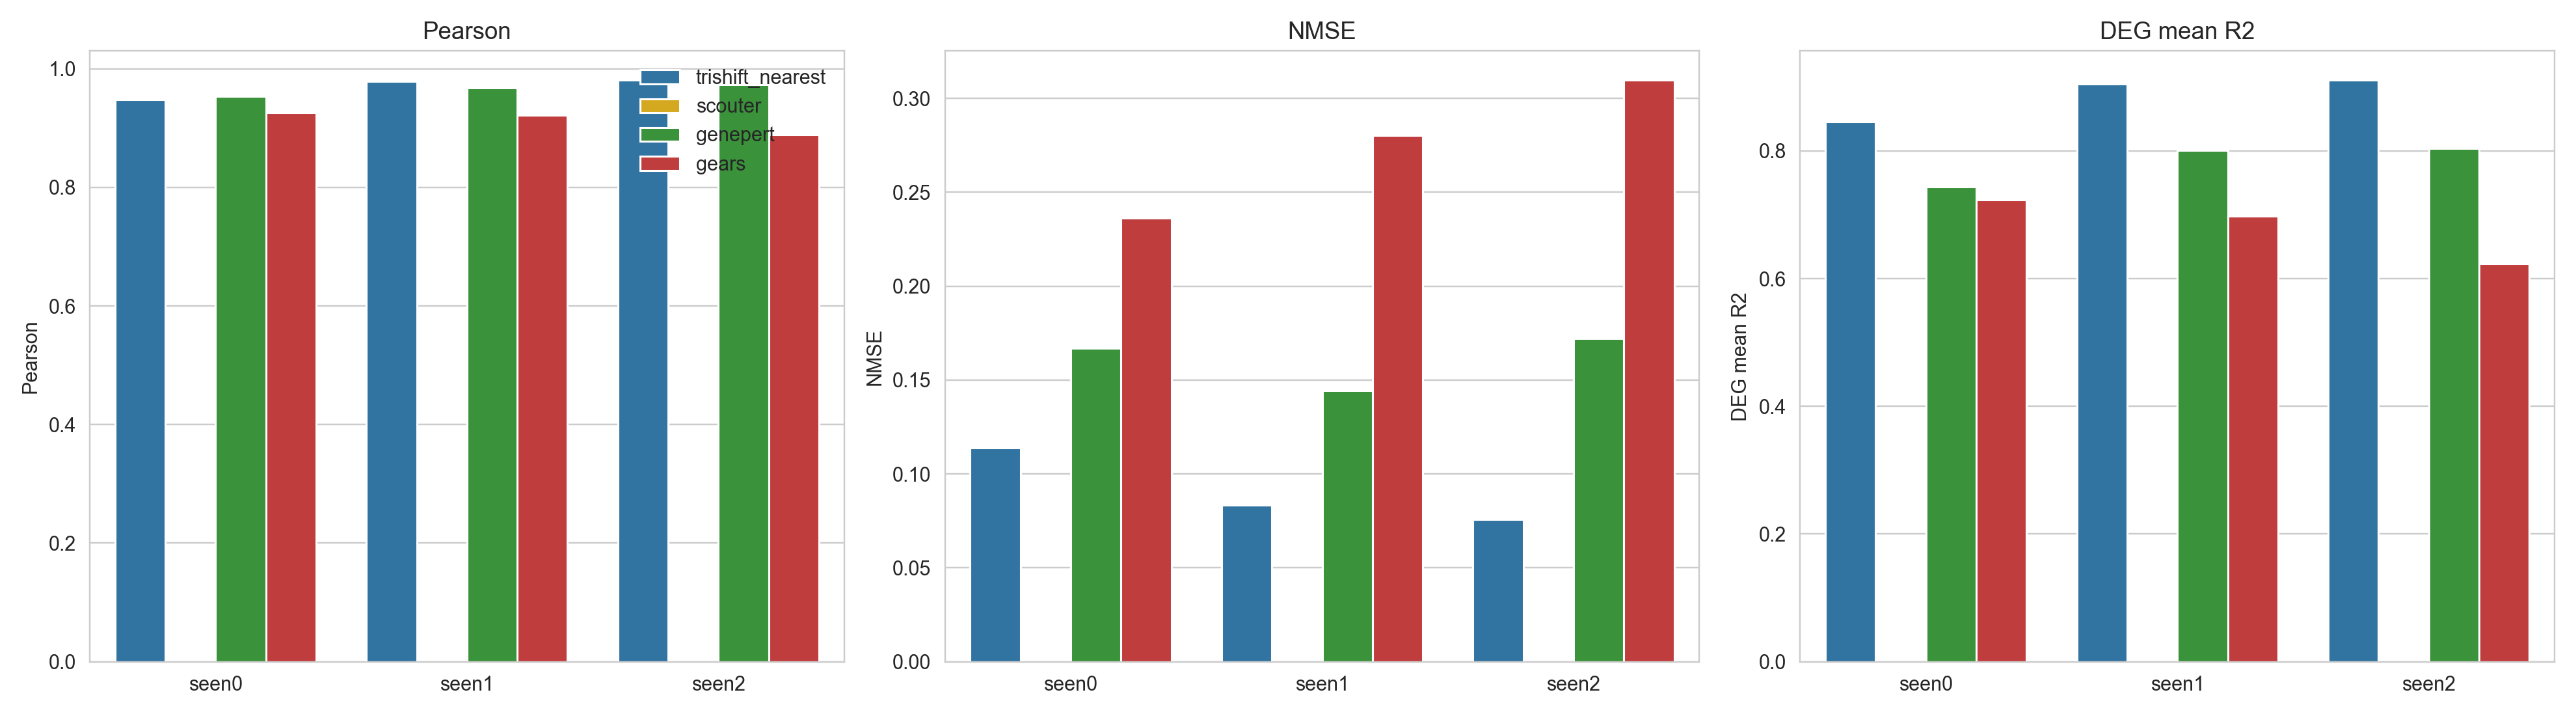

e:\CODE\trishift\notebooks\artifacts\norman_subgroup_compare\norman_subgroup_pearson_barplot.png
e:\CODE\trishift\notebooks\artifacts\norman_subgroup_compare\norman_subgroup_nmse_barplot.png
e:\CODE\trishift\notebooks\artifacts\norman_subgroup_compare\norman_subgroup_deg_mean_r2_barplot.png
e:\CODE\trishift\notebooks\artifacts\norman_subgroup_compare\norman_subgroup_metric_panel.png
e:\CODE\trishift\notebooks\artifacts\norman_subgroup_compare\norman_subgroup_metrics.csv


In [4]:
barplot_paths = []
for metric, label in metric_map.items():
    fig_path = out_root / f"norman_subgroup_{metric}_barplot.png"
    plt.figure(figsize=(6.2, 4.8), dpi=220)
    work = summary_df.copy()
    work["model_name"] = pd.Categorical(work["model_name"], categories=model_order, ordered=True)
    ax = sns.barplot(data=work, x="subgroup", y=metric, hue="model_name", palette=palette, order=["seen0", "seen1", "seen2"], hue_order=model_order, estimator="median", errorbar=None)
    for bar in ax.patches:
        bar.set_edgecolor("black")
        bar.set_linewidth(0.5)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_title(f"Norman subgroup comparison: {label}")
    ax.legend(title="", frameon=False)
    plt.tight_layout()
    plt.savefig(fig_path)
    plt.close()
    barplot_paths.append(fig_path)

fig, axes = plt.subplots(1, len(barplot_paths), figsize=(6 * len(barplot_paths), 5), dpi=220)
axes = axes if isinstance(axes, (list, tuple)) else [axes] if len(barplot_paths) == 1 else axes
for ax, metric, label in zip(axes, metric_map.keys(), metric_map.values()):
    work = summary_df.copy()
    work["model_name"] = pd.Categorical(work["model_name"], categories=model_order, ordered=True)
    sns.barplot(data=work, x="subgroup", y=metric, hue="model_name", palette=palette, order=["seen0", "seen1", "seen2"], hue_order=model_order, estimator="median", errorbar=None, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_title(label)
    if ax is not axes[0]:
        ax.get_legend().remove()
    else:
        ax.legend(title="", frameon=False)
panel_path = out_root / "norman_subgroup_metric_panel.png"
plt.tight_layout()
plt.savefig(panel_path)
plt.close()
display(Image(filename=str(panel_path), width=1400))
for path in barplot_paths + [panel_path, out_root / "norman_subgroup_metrics.csv"]:
    print(path)
